In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import time

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1289s 8us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


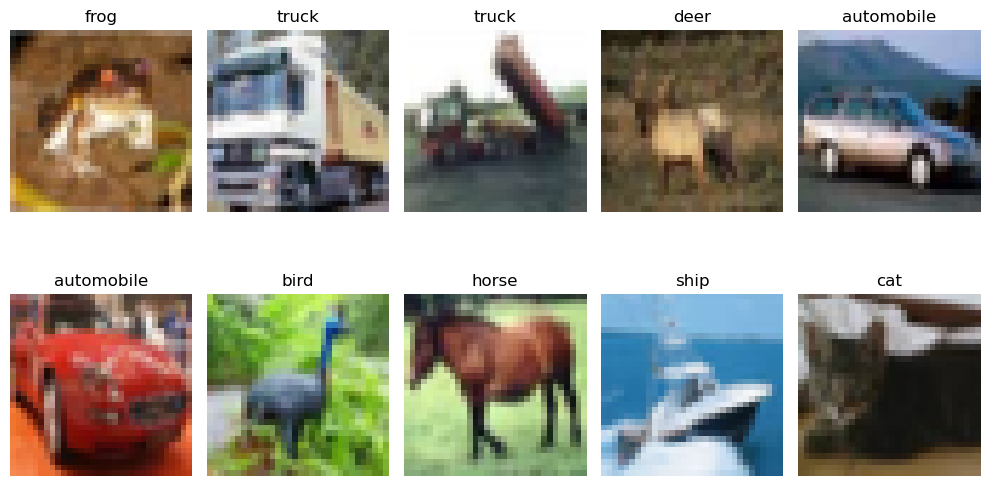

In [3]:
# Display sample images
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Function to create the CNN model
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation="softmax")
    ])
    return model

In [5]:
# Compare different optimizers
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories = {}
results = {}

EPOCHS = 10
BATCH_SIZE = 64

for name, optimizer in optimizers.items():
    print(f"\nTraining with {name} optimizer...")

    model = create_model()
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=1
    )
    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    histories[name] = history.history
    results[name] = {
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Training Time (sec)": training_time
    }


Training with SGD optimizer...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 148ms/step - accuracy: 0.2062 - loss: 2.1445 - val_accuracy: 0.3135 - val_loss: 1.9536
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.3197 - loss: 1.8961 - val_accuracy: 0.3863 - val_loss: 1.7411
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.3803 - loss: 1.7277 - val_accuracy: 0.4275 - val_loss: 1.6175
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.4279 - loss: 1.5997 - val_accuracy: 0.4560 - val_loss: 1.5263
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.4549 - loss: 1.5171 - val_accuracy: 0.4759 - val_loss: 1.4557
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.4819 - loss: 1.4575 - val_accuracy: 0.5122 - val_loss: 1.3708
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.5234 - loss: 1.3501 - val_accuracy: 0.5477 - val_loss: 1.2804
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/

In [10]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df)

         Test Accuracy  Test Loss  Training Time (sec)
SGD             0.5699     1.1968             957.7734
RMSprop         0.7326     0.9019            1120.9891
Adam            0.7309     0.9568            1037.9966


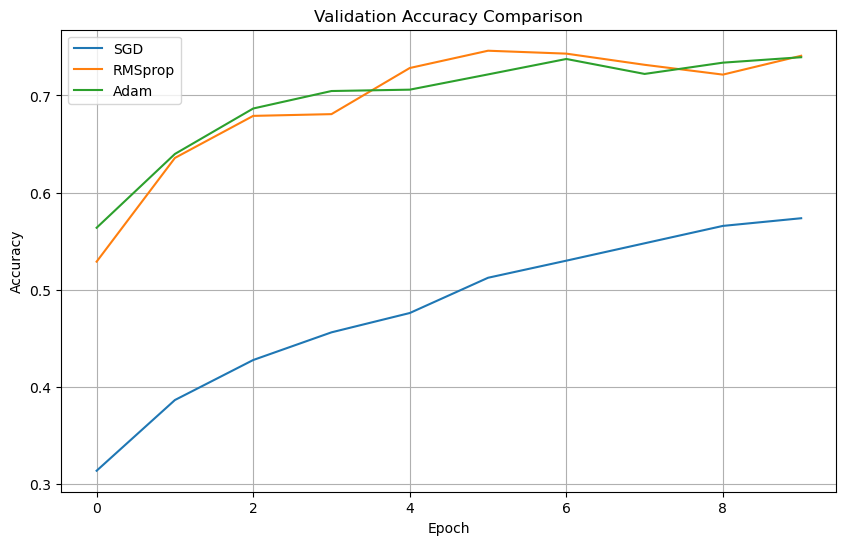

In [11]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history["val_accuracy"], label=name)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

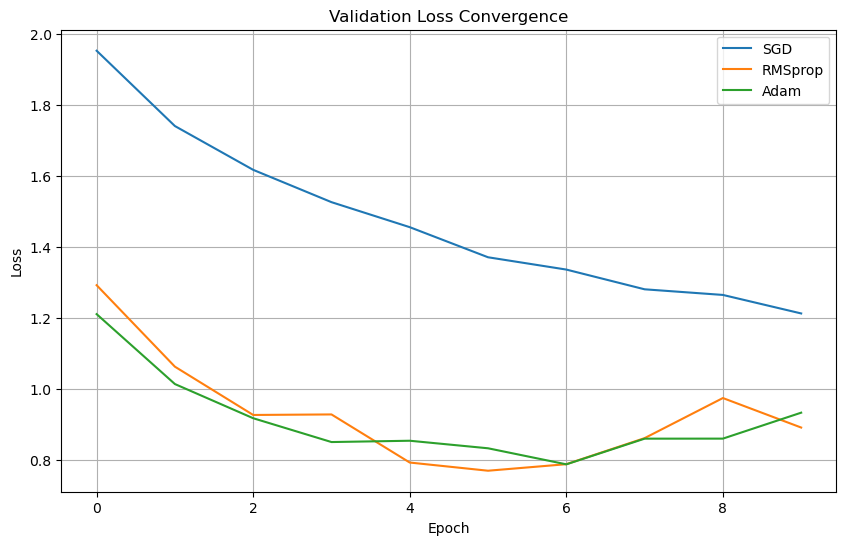

In [12]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history["val_loss"], label=name)

plt.title("Validation Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()